In [1]:
import numpy as np              #to load & clean
import pandas as pd             #for calculations
import matplotlib.pyplot as plt    #for charts
import scipy.stats as stats       #for statistical tests


In [8]:
#load the data 
df = pd.read_csv("data/Pakwheels.csv")
print("Rows and columns:", df.shape)
df.head()

Rows and columns: (89956, 17)


,Unnamed: 0,ad_url,title,location,model_year,price,mileage,engine_type,transmission,registered_in,color,assembly,engine_capacity,body_type,ad_last_updated,car_features,description
0,0,https://www.pakwheels.com/used-cars/honda-civi...,Honda Civic VTi Oriel Prosmatec 1.8 i-VTEC 2007,Islamabad Islamabad,2007.0,PKR 16.5 lacs,"100,000 km",Petrol,Automatic,Lahore,Grey,Imported Cars,1800 cc,Sedan,"Oct 09, 2022",ABS\nAM/FM Radio\nAir Bags\nAir Conditioning\n...,2007 model full option Chat piller geniune or ...
1,1,https://www.pakwheels.com/used-cars/suzuki-meh...,Suzuki Mehran VX Euro II 2012,"Eden Gardens, Faisalabad Punjab",2012.0,PKR 7 lacs,"100,000 km",Petrol,Manual,Faisalabad,Grey,Imported Cars,800 cc,Hatchback,"Oct 09, 2022",AM/FM Radio\nCD Player\nImmobilizer Key,"Very smooth drive,70% in orignal paint rest of..."
2,2,https://www.pakwheels.com/used-cars/honda-civi...,Honda Civic EX 1995,"Bostan Road, Rawalpindi Punjab",1995.0,PKR 7.6 lacs,999 km,Petrol,Manual,Lahore,Black,Imported Cars,1500 cc,Sedan,"Oct 09, 2022",AM/FM Radio\nAir Conditioning\nAlloy Rims\nCas...,1600cc Engine installed Alloy RimsAir Conditio...
3,3,https://www.pakwheels.com/used-cars/toyota-for...,Toyota Fortuner 2.7 VVTi 2013,"Kallar Kahar Road, Chakwal Punjab",2013.0,PKR 70 lacs,"94,000 km",Petrol,Automatic,Lahore,Black,Imported Cars,2700 cc,SUV,"Oct 09, 2022",ABS\nAM/FM Radio\nAir Bags\nAir Conditioning\n...,Inside out fully original. Original return fil...
4,4,https://www.pakwheels.com/used-cars/suzuki-meh...,Suzuki Mehran VX Euro II 2015,Muzaffar Gargh Punjab,2015.0,PKR 8 lacs,"86,000 km",Petrol,Manual,Multan,Grey,Imported Cars,796 cc,Hatchback,"Oct 09, 2022",AM/FM Radio\nCD Player\nImmobilizer Key,gari total genion hy.chill a.c.new tires.no wo...


In [9]:
#Check missing values & data info
df.info()
missing = df.isnull().sum()
print("\nMissing values per column:\n", missing)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 89956 entries, 0 to 89955
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Unnamed: 0       89956 non-null  int64  
 1   ad_url           89956 non-null  object 
 2   title            89956 non-null  object 
 3   location         89954 non-null  object 
 4   model_year       87449 non-null  float64
 5   price            89954 non-null  object 
 6   mileage          89954 non-null  object 
 7   engine_type      89001 non-null  object 
 8   transmission     89954 non-null  object 
 9   registered_in    89954 non-null  object 
 10  color            88093 non-null  object 
 11  assembly         89956 non-null  object 
 12  engine_capacity  89954 non-null  object 
 13  body_type        81407 non-null  object 
 14  ad_last_updated  89954 non-null  object 
 15  car_features     83435 non-null  object 
 16  description      89954 non-null  object 
dtypes: float64(1

In [11]:
# Drop duplicate rows
df = df.drop_duplicates()

if 'price' in df.columns:
    df['price'] = df['price'].astype(str).str.lower()

    df['price'] = df['price'].str.replace('million', '*1000000', regex=False)
    df['price'] = df['price'].str.replace('lac', '*100000', regex=False)
    df['price'] = df['price'].str.replace('crore', '*10000000', regex=False)
    df['price'] = df['price'].str.replace('crores', '*10000000', regex=False)
    df['price'] = df['price'].str.replace(r'[^\d.*]', '', regex=True)

    # Remove entries like "call for price" (make them empty so they become NaN later)
    df['price'] = df['price'].str.replace('call for price', '', regex=False)
    df['price'] = df['price'].str.replace('call', '', regex=False)
    df['price'] = df['price'].str.replace('price on call', '', regex=False)
    # Safely evaluate expressions like "2.5*1000000"
    def safe_eval(x):
        try:
            return eval(x)
        except:
            return np.nan

    df['price'] = df['price'].apply(safe_eval)

for col in ['mileage', 'engine_capacity', 'year']:
    if col in df.columns:
        df[col] = (
            df[col]
            .astype(str)
            .str.replace(r'[^\d.]', '', regex=True)
            .replace('', np.nan)
        )
        df[col] = pd.to_numeric(df[col], errors='coerce')

df = df.dropna(subset=['price'])
df = df[df['price'] > 0]

print("After cleaning, rows:", len(df))
df.head()


After cleaning, rows: 88549


,Unnamed: 0,ad_url,title,location,model_year,price,mileage,engine_type,transmission,registered_in,color,assembly,engine_capacity,body_type,ad_last_updated,car_features,description
0,0,https://www.pakwheels.com/used-cars/honda-civi...,Honda Civic VTi Oriel Prosmatec 1.8 i-VTEC 2007,Islamabad Islamabad,2007.0,1650000.0,100000.0,Petrol,Automatic,Lahore,Grey,Imported Cars,1800.0,Sedan,"Oct 09, 2022",ABS\nAM/FM Radio\nAir Bags\nAir Conditioning\n...,2007 model full option Chat piller geniune or ...
1,1,https://www.pakwheels.com/used-cars/suzuki-meh...,Suzuki Mehran VX Euro II 2012,"Eden Gardens, Faisalabad Punjab",2012.0,700000.0,100000.0,Petrol,Manual,Faisalabad,Grey,Imported Cars,800.0,Hatchback,"Oct 09, 2022",AM/FM Radio\nCD Player\nImmobilizer Key,"Very smooth drive,70% in orignal paint rest of..."
2,2,https://www.pakwheels.com/used-cars/honda-civi...,Honda Civic EX 1995,"Bostan Road, Rawalpindi Punjab",1995.0,760000.0,999.0,Petrol,Manual,Lahore,Black,Imported Cars,1500.0,Sedan,"Oct 09, 2022",AM/FM Radio\nAir Conditioning\nAlloy Rims\nCas...,1600cc Engine installed Alloy RimsAir Conditio...
3,3,https://www.pakwheels.com/used-cars/toyota-for...,Toyota Fortuner 2.7 VVTi 2013,"Kallar Kahar Road, Chakwal Punjab",2013.0,7000000.0,94000.0,Petrol,Automatic,Lahore,Black,Imported Cars,2700.0,SUV,"Oct 09, 2022",ABS\nAM/FM Radio\nAir Bags\nAir Conditioning\n...,Inside out fully original. Original return fil...
4,4,https://www.pakwheels.com/used-cars/suzuki-meh...,Suzuki Mehran VX Euro II 2015,Muzaffar Gargh Punjab,2015.0,800000.0,86000.0,Petrol,Manual,Multan,Grey,Imported Cars,796.0,Hatchback,"Oct 09, 2022",AM/FM Radio\nCD Player\nImmobilizer Key,gari total genion hy.chill a.c.new tires.no wo...


In [12]:
#Descriptive statis
numeric_cols = df.select_dtypes(include=[np.number]).columns
print(df[numeric_cols].describe())


         Unnamed: 0    model_year         price         mileage  \
count  88549.000000  86046.000000  8.854900e+04    88549.000000   
mean   45089.181007   2012.767020  2.465403e+06    85061.127782   
std    25970.475402      7.671057  1.888061e+06    90745.182346   
min        0.000000   1990.000000  1.000000e+00        1.000000   
25%    22666.000000   2007.000000  1.050000e+06    20000.000000   
50%    45121.000000   2014.000000  2.000000e+06    75000.000000   
75%    67717.000000   2019.000000  3.350000e+06   120000.000000   
max    89955.000000   2022.000000  1.000000e+07  1000000.000000   

       engine_capacity  
count     88549.000000  
mean       1398.680950  
std         731.660795  
min          16.500000  
25%        1000.000000  
50%        1300.000000  
75%        1600.000000  
max       15000.000000  


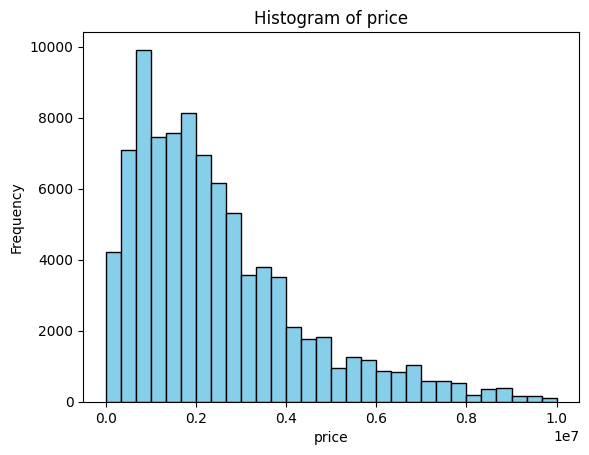

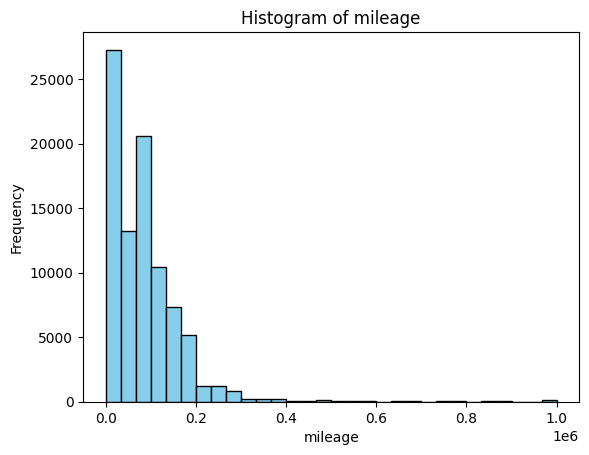

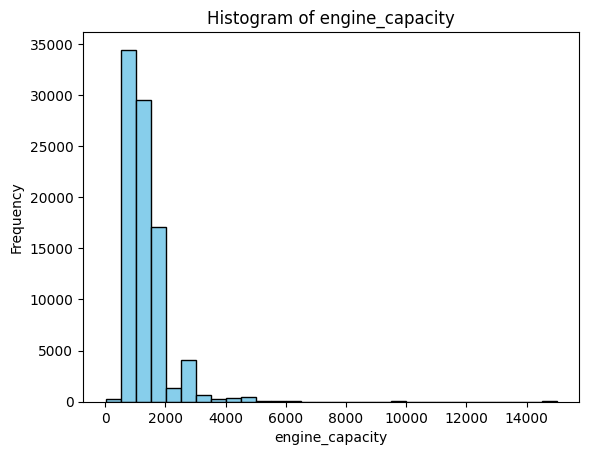

In [13]:
# Histograms for numeric columns
for col in ['price', 'mileage', 'engine_capacity']:
    if col in df.columns:
        plt.hist(df[col].dropna(), bins=30, color='skyblue', edgecolor='black')
        plt.title(f"Histogram of {col}")
        plt.xlabel(col)
        plt.ylabel("Frequency")
        plt.show()
        

Price: Most cars are low-priced, with a few very expensive ones ,it's Right-skewed.
Mileage: Most cars have low mileage, and a few have very high mileage, it's Right-skewed.
Engine Capacity: Most cars have small engines, and a few have very large engines , it's Right-skewed.

In [14]:
# One-sample t-test 
sample = df['price'].dropna()
mean_price = np.mean(sample)
std_price = np.std(sample, ddof=1)
n = len(sample)
hypothesized_value = 2000000

# t-test
t_stat, p_value = stats.ttest_1samp(sample, popmean=hypothesized_value)

print("Sample size:", n)
print("Sample mean:", mean_price)
print("t-statistic:", t_stat)
print("p-value:", p_value)

# 95% Confidence interval
alpha = 0.05
t_crit = stats.t.ppf(1 - alpha/2, n-1)
margin = t_crit * (std_price / np.sqrt(n))
ci_low = mean_price - margin
ci_high = mean_price + margin
print(f"95% CI for mean = [{ci_low:.2f}, {ci_high:.2f}]")


Sample size: 88549
Sample mean: 2465402.5470365565
t-statistic: 73.35075299121651
p-value: 0.0
95% CI for mean = [2452966.62, 2477838.48]


the p-value is almost 0 (less than 0.05), we reject the null hypothesis.
This means the average car price is significantly higher than 2,000,000.
The 95% confidence interval also does not include 2,000,000, supporting the same conclusion.

In [15]:
# Two-sample t-test
auto = df[df['transmission'] == 'Automatic']['price'].dropna()
manual = df[df['transmission'] == 'Manual']['price'].dropna()

print("Automatic cars:", len(auto))
print("Manual cars:", len(manual))

# Two-sample t-test (unequal variances)
t_stat, p_value = stats.ttest_ind(auto, manual, equal_var=False)

print("t-statistic:", t_stat)
print("p-value:", p_value)

if p_value < 0.05:
    print("Result: Prices are significantly different.")
else:
    print("Result: No significant difference in prices.")


Automatic cars: 45273
Manual cars: 43276
t-statistic: 185.98087569921054
p-value: 0.0
Result: Prices are significantly different.


the p-value is much less than 0.05, so i reject the null hypothesis.
This means there is a significant difference in prices between Automatic and Manual cars.
The large t-statistic also confirms that the difference is strong and statistically meaningful.

In [16]:
# Multiple group comparison

# Extract brand from title (first word)
df['brand'] = df['title'].astype(str).str.split().str[0]
top_brands = df['brand'].value_counts().head(3).index
df3 = df[df['brand'].isin(top_brands)]

# Group prices by brand
groups = [df3[df3['brand'] == b]['price'].dropna() for b in top_brands]

# Kruskal-Wallis test 
stat, p_value = stats.kruskal(*groups)

print("Brands tested:", list(top_brands))
print("Kruskal-Wallis statistic:", stat)
print("p-value:", p_value)

if p_value < 0.05:
    print("Result: Price differs between brands.")
else:
    print("Result: No significant difference between brands.")


Brands tested: ['Toyota', 'Suzuki', 'Honda']
Kruskal-Wallis statistic: 17496.296058835662
p-value: 0.0
Result: Price differs between brands.


the p-value is less than 0.05, i reject the null hypothesis.
This means that car prices are not the same across Toyota, Suzuki, and Honda.
At least one brand has a significantly different price distribution compared to the others.

In [17]:
#  Correlation 
num_cols = ['price', 'mileage', 'engine_capacity', 'year']
num_cols = [c for c in num_cols if c in df.columns]

corr_matrix = df[num_cols].corr(method='pearson')
print("Correlation matrix:\n", corr_matrix)


Correlation matrix:
                     price   mileage  engine_capacity
price            1.000000 -0.249840         0.296652
mileage         -0.249840  1.000000         0.041092
engine_capacity  0.296652  0.041092         1.000000


Price vs Mileage:
There is a weak negative correlation (-0.25), cars with higher mileage usually have slightly lower prices.
Price vs Engine Capacity:
There is a moderate positive correlation (0.30),cars with larger engines tend to have higher prices.
Mileage vs Engine Capacity:
There is almost no correlation (0.04),engine size doesn’t affect mileage directly

Bootstrap 95% CI for mean difference = [1959247.35, 1998976.97]


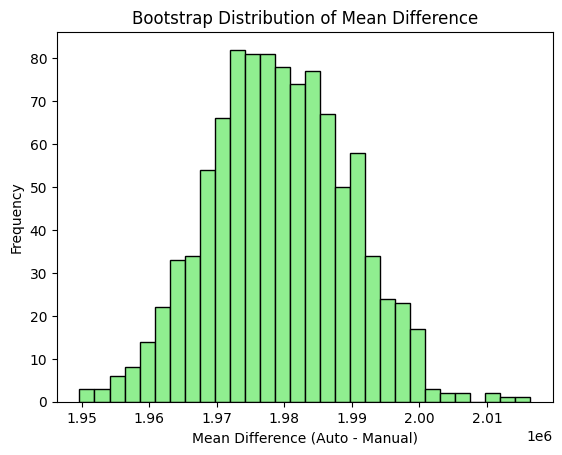

In [18]:
#  Bootstrapping mean difference
auto = auto.dropna().values
manual = manual.dropna().values
np.random.seed(42)

boot_diffs = []
for i in range(1000):
    boot_auto = np.random.choice(auto, size=len(auto), replace=True)
    boot_manual = np.random.choice(manual, size=len(manual), replace=True)
    boot_diffs.append(np.mean(boot_auto) - np.mean(boot_manual))

# 95% CI from bootstrap
lower = np.percentile(boot_diffs, 2.5)
upper = np.percentile(boot_diffs, 97.5)
print(f"Bootstrap 95% CI for mean difference = [{lower:.2f}, {upper:.2f}]")

plt.hist(boot_diffs, bins=30, color='lightgreen', edgecolor='black')
plt.title("Bootstrap Distribution of Mean Difference")
plt.xlabel("Mean Difference (Auto - Manual)")
plt.ylabel("Frequency")
plt.show()


The bootstrap distribution is roughly bell-shaped and centered around 1.98 million, showing the average price difference between automatic and manual cars.
The 95% confidence interval does not include zero, which means the price difference is statistically significant ,so automatic cars are clearly more expensive on average